In [1]:
import cProfile

def sum_():
    total_sum = 0
    # sum of numbers till 10000
    for i in range(0,10001):
        total_sum += i 
    return total_sum

cProfile.run('sum_()')

         4 function calls in 0.001 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.001    0.001    0.001    0.001 196336709.py:3(sum_)
        1    0.000    0.000    0.001    0.001 <string>:1(<module>)
        1    0.000    0.000    0.001    0.001 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}




In [2]:
from fastbook import *
from ddgs import DDGS

In [13]:
results = DDGS().images(query="bird photo", region="en-us", safesearch="off", max_results=1)
results

[{'title': '507 Colorful Bird Pictures · Pexels · Free Stock Photos',
  'image': 'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg',
  'thumbnail': 'https://tse3.mm.bing.net/th/id/OIP.3hTkhdPZ8PRL3R6saGGNAgHaE7?pid=Api',
  'url': 'https://www.pexels.com/search/bird/',
  'height': 1333,
  'width': 2000,
  'source': 'Bing'}]

In [14]:
for result in results:
    print(result["image"])

https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg


In [17]:
dest = Path('./bird.jpg')
if not dest.exists():
    download_url(results[0]["image"], dest)

<div><progress max="173489" value="180224"></progress> 103.88% [180224/173489 00:00&lt;00:00]</div>

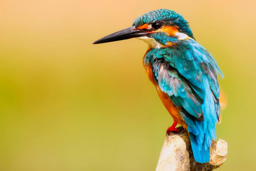

In [18]:
im = Image.open(dest)
im.to_thumb(256, 256)

In [34]:
searches = "forest", "bird"
path = Path("bird_or_not")
    
if path.exists():
    for o in searches:
        dest = (path/o)
        dest.mkdir(exist_ok=True)
        results = DDGS().images(query=f"{o} photo", region="en-us", safesearch="off", max_results=200)
        download_images(dest=dest, urls=[result['image'] for result in results])
        resize_images(dest, dest=dest, max_size=400)

In [35]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[None, None]

In [36]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')],
).dataloaders(path)

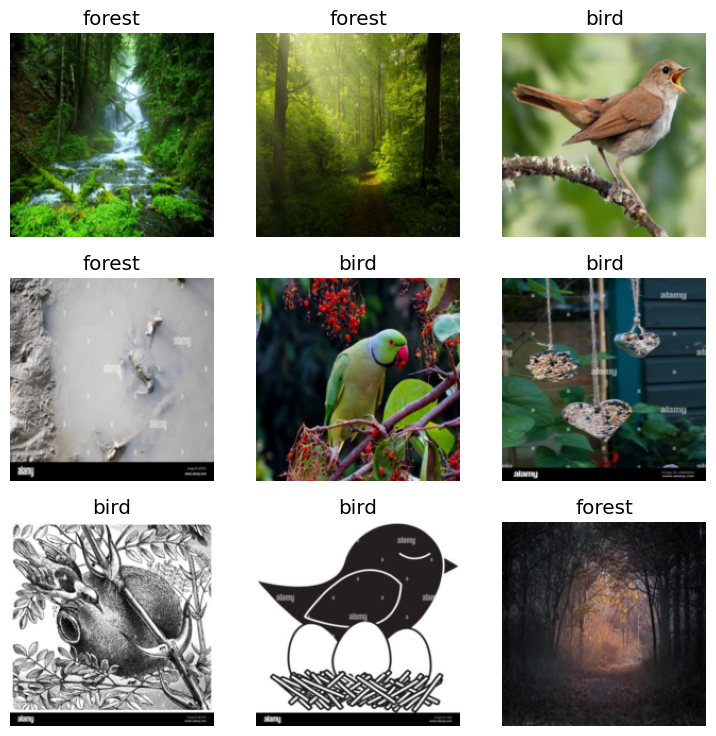

In [37]:
dls.show_batch(max_n=9)

In [41]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.remove_cb(ProgressCallback)
learn.fine_tune(3)

[0, 0.9343894720077515, 0.3382652699947357, 0.1666666865348816, '00:03']
[0, 0.36704760789871216, 0.4058237075805664, 0.08333331346511841, '00:04']
[1, 0.21501757204532623, 0.48061883449554443, 0.1111111044883728, '00:04']
[2, 0.15282408893108368, 0.4167642891407013, 0.1111111044883728, '00:04']


In [42]:
is_bird, _, probs = learn.predict(PILImage.create('bird.jpg'))
print(f'This is a {is_bird}, with a probability of {probs[0]:.4f}')

This is a bird, with a probability of 1.0000
